Coordinate trovate: 40.8523482, 14.2698708


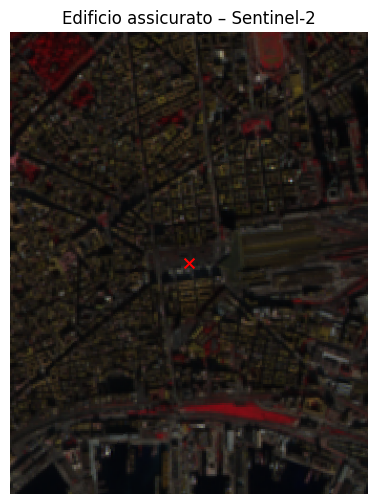

Immagine salvata con marker!


In [ ]:
import pandas as pd
from geopy.geocoders import Nominatim
from sentinelhub import (
    SHConfig, SentinelHubRequest, DataCollection,
    bbox_to_dimensions, BBox, CRS, MimeType
)
import matplotlib.pyplot as plt

# ---------------------------------------
# CONFIGURAZIONE SENTINEL HUB
# ---------------------------------------
config = SHConfig()
config.sh_client_id = "4be159ec-b48b-44cb-99fa-dafcf22b5fdb"
config.sh_client_secret = "ptZ6Z8Fl2RRK6b8znfASXHEDKz9KLCCH"

# ---------------------------------------
# 1. LEGGI PRIMA RIGA CSV
# ---------------------------------------
df = pd.read_csv("abitazioni.csv")
row = df.iloc[0]

indirizzo = f"{row['Indirizzo']}, {row['Luogo di Residenza']}, Italia"

# ---------------------------------------
# 2. GEOCODING INDIRIZZO → COORDINATE
# ---------------------------------------
geolocator = Nominatim(user_agent="ai-challenge", timeout=10)
location = geolocator.geocode(indirizzo)

lat, lon = location.latitude, location.longitude

print(f"Coordinate trovate: {lat}, {lon}")

# ---------------------------------------
# 3. CREA BOUNDING BOX (100m)
# ---------------------------------------
dx = 0.01
dy = 0.01
bbox = BBox([lon - dx, lat - dy, lon + dx, lat + dy], CRS.WGS84)
size = bbox_to_dimensions(bbox, resolution=10)

request = SentinelHubRequest(
    evalscript="""
        //VERSION=3
        function setup() {
            return {input: ["B08","B04","B03"], output: {bands:3}};
        }
        function evaluatePixel(sample) {
            return [sample.B08, sample.B04, sample.B03];
        }
    """,
    input_data=[SentinelHubRequest.input_data(
        data_collection=DataCollection.SENTINEL2_L2A,
        time_interval=("2024-01-01","2024-12-31"),
        mosaicking_order="mostRecent"
    )],
    responses=[SentinelHubRequest.output_response("default", MimeType.PNG)],
    bbox=bbox,
    size=size,
    config=config
)
image = request.get_data()[0]

# -----------------------------
# Mostra immagine con marker
# -----------------------------
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.title("Edificio assicurato – Sentinel-2")

# Calcolo posizione marker in pixel
height, width, _ = image.shape
# SentinelHub restituisce array con [0,0] in alto a sinistra
marker_x = width // 2
marker_y = height // 2

# Aggiungi marker rosso
plt.scatter(marker_x, marker_y, c='red', s=50, marker='x')

# Salva immagine con marker
plt.savefig("immobile_sentinel2_marker.png", dpi=200)
plt.show()

print("Immagine salvata con marker!")


In [ ]:
import pandas as pd
import geopandas as gpd
from shapely import distance
from shapely.geometry import Point
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from sentinelhub import (
    SHConfig, SentinelHubRequest, DataCollection,
    bbox_to_dimensions, BBox, CRS, MimeType
)
import requests
import osmnx as ox
import numpy as np
from pyproj import Transformer
import time

# ---------------------------------------
# CONFIGURAZIONE SENTINEL HUB
# ---------------------------------------
config = SHConfig()
config.sh_client_id = "4be159ec-b48b-44cb-99fa-dafcf22b5fdb"
config.sh_client_secret = "ptZ6Z8Fl2RRK6b8znfASXHEDKz9KLCCH"

# -----------------------------
# 1. LEGGI PRIMA RIGA CSV
# -----------------------------
df = pd.read_csv("abitazioni.csv")
row = df.iloc[0]

indirizzo = f"{row['Indirizzo']}, {row['Luogo di Residenza']}, Italia"

# -----------------------------
# 2. GEOCODING
# -----------------------------
geolocator = Nominatim(user_agent="ai-challenge", timeout=60)

# Limita la velocità per evitare blocchi
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

location = geocode(indirizzo)
if location:
    lat, lon = location.latitude, location.longitude
    print(f"Coordinate: {lat}, {lon}")
else:
    print("Indirizzo non trovato")

# -----------------------------
# 3. ALTITUDINE (Open Elevation API)
# -----------------------------
elevation_url = f"https://api.open-elevation.com/api/v1/lookup?locations={lat},{lon}"
elevation = requests.get(elevation_url).json()["results"][0]["elevation"]

# -----------------------------
# 4. TIPO DI AREA (OSM – landuse)
# -----------------------------
"""
es:
residential
industrial
commercial
farmland
forest
"""
overpass_query = f"""
[out:json];
(
  way["landuse"](around:500,{lat},{lon});
  relation["landuse"](around:500,{lat},{lon});
);
out tags;
"""

response = requests.post(
    "https://overpass-api.de/api/interpreter",
    data=overpass_query,
    timeout=10
)

if response.status_code != 200:
    print(f"Errore tipo di area: {response.status_code}")
    print(response.text[:100])
else:
    try:
        osm_response = response.json()
    except ValueError as e:
        print("JSONDecodeError:", e)
        print(response.text[:100])
        osm_response = {"elements": []}

landuse = "unknown"
if osm_response["elements"]:
    landuse = osm_response["elements"][0]["tags"].get("landuse", "unknown")

# -----------------------------
# 5. STIMA PENDENZA (proxy)
# -----------------------------
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32633", always_xy=True)
x, y = transformer.transform(lon, lat)

buffer = 150  # metri
bbox = BBox(
    [x-buffer, y-buffer, x+buffer, y+buffer],
    crs=CRS.UTM_33N
)

size = bbox_to_dimensions(bbox, resolution=10)  # DEM reale

evalscript_dem = """
//VERSION=3
function setup() {
  return {
    input: ["DEM"],
    output: { bands: 1, sampleType: "FLOAT32" }
  };
}

function evaluatePixel(sample) {
  return [sample.DEM];
}
"""
dem_request = SentinelHubRequest(
    evalscript=evalscript_dem,
    input_data=[SentinelHubRequest.input_data(
        data_collection=DataCollection.DEM,
        time_interval=("2024-01-01", "2024-12-31")
    )],
    responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
    bbox=bbox,
    size=size,
    config=config
)

dem = dem_request.get_data()[0]  # matrice quote
# dimensione pixel (metri)
pixel_size = 10  # metri (Copernicus DEM)

center = dem.shape[0] // 2
window = dem[center-2:center+3, center-2:center+3]  # finestra 5x5 intorno al punto

dz_dx = np.gradient(window, axis=1) / pixel_size
dz_dy = np.gradient(window, axis=0) / pixel_size

slope_rad = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))
slope_pct = np.tan(slope_rad) * 100

slope = np.mean(slope_pct)
if slope < 5:
    rischio = "Basso"
elif slope < 15:
    rischio = "Medio"
elif slope < 30:
    rischio = "Alto"
else:
    rischio = "Molto alto"

# -----------------------------
# 6. RISCHIO ALLUVIONE (proxy)
# -----------------------------
# Define OSM tags for water
tags = {
    "natural": ["water"]           # laghi, stagni, bacini naturali
}
distance = 1000  # metri
gdf = ox.features.features_from_point(
            (lat, lon),
            tags=tags,
            dist=distance
        )
gdf_named = gdf[gdf['name'].notnull()]

point = Point(lon, lat)
# Converti in CRS metrico per avere distanze in metri
gdf_named = gdf_named.to_crs(epsg=3857)
point_proj = gpd.GeoSeries([point], crs="EPSG:4326").to_crs(epsg=3857).iloc[0]

# Aggiungi colonna distanza
gdf_named['distance'] = gdf_named.geometry.distance(point_proj)
closest = gdf_named.loc[gdf_named['distance'].idxmin()]
min_dist = round(closest['distance'], 2) if not gdf_named.empty else float('inf')

# Thresholds personalizzabili
if elevation < 5 and min_dist < 50:
    flood_risk = "molto alto"
elif elevation < 10 and min_dist < 100:
    flood_risk = "alto"
elif elevation < 20 and min_dist < 200:
    flood_risk = "medio"
else:
    flood_risk = "basso"

# Considera anche pendenza: zone pianeggianti -> rischio più alto
if slope < 5 and flood_risk in ["medio", "alto"]:
    flood_risk = "alto" if flood_risk == "medio" else "molto alto"

# -----------------------------
# 7. RISCHIO FRANA (proxy)
# -----------------------------
def get_soil_profile_retry(lat, lon, retries=3, delay=5):
    depths = ["0-5cm", "5-15cm", "15-30cm", "30-60cm", "60-100cm"]
    url = f"https://rest.isric.org/soilgrids/v2.0/properties/query?lon={lon}&lat={lat}&property=taxnwrb"

    for attempt in range(retries):
        try:
            response = requests.get(url, timeout=30)
            response.raise_for_status()
            data = response.json()
            classes = data.get("properties", {}).get("taxnwrb", {}).get("classes", {})

            soil_profile = {d: classes.get(d, {}).get("dominant", "unknown") for d in depths}
            dominant_soil = next((s for s in soil_profile.values() if s != "unknown"), "unknown")
            return dominant_soil, soil_profile

        except requests.exceptions.RequestException as e:
            print(f"Tentativo {attempt+1} fallito: {e}")
            time.sleep(delay)

    # se tutti i tentativi falliscono
    print("Impossibile ottenere il profilo del suolo, ritorno valori 'unknown'")
    return "unknown", {d: "unknown" for d in depths}

dominant_soil, soil_profile = get_soil_profile_retry(lat, lon)

landslide_risk = "basso"
if slope == "alta" and elevation > 400:
    landslide_risk = "medio"
if slope == "alta" and elevation > 700:
    landslide_risk = "alto"

# -----------------------------
# 8. OUTPUT FEATURE TERRITORIALI
# -----------------------------
territory_features = {
    "indirizzo": indirizzo,
    "latitudine": lat,
    "longitudine": lon,
    "altitudine_m": elevation,
    "landuse": landuse,
    "pendenza": f"{slope:.2f}% ({rischio})",
    "closest_object_name": closest.get('name', 'unknown'),
    "closest_object_distance_m": min_dist,
    "rischio_alluvione": flood_risk,
    "tipo_suolo_dominante": dominant_soil,
    "profilo_suolo_0-100cm": soil_profile,
    "rischio_frana": landslide_risk
}

print("\n📍 FEATURE TERRITORIALI ESTRATTE:")
for k, v in territory_features.items():
    print(f"{k}: {v}")


Coordinate: 40.852392, 14.2696473
Errore tipo di area: 504
<?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Strict//EN"
    
Tentativo 1 fallito: 502 Server Error: Bad Gateway for url: https://rest.isric.org/soilgrids/v2.0/properties/query?lon=14.2696473&lat=40.852392&property=taxnwrb
Tentativo 2 fallito: 502 Server Error: Bad Gateway for url: https://rest.isric.org/soilgrids/v2.0/properties/query?lon=14.2696473&lat=40.852392&property=taxnwrb
Tentativo 3 fallito: 502 Server Error: Bad Gateway for url: https://rest.isric.org/soilgrids/v2.0/properties/query?lon=14.2696473&lat=40.852392&property=taxnwrb
Impossibile ottenere il profilo del suolo, ritorno valori 'unknown'

📍 FEATURE TERRITORIALI ESTRATTE:
indirizzo: Piazza Garibaldi, 91, Napoli, Italia
latitudine: 40.852392
longitudine: 14.2696473
altitudine_m: 21.0
landuse: grass
pendenza: 4.71% (Basso)
closest_object_name: Fontana della Scapigliata
closest_object_distance_m: 637.57
rischio_alluvione: bas